In [1]:
import kagglehub
 
path = kagglehub.dataset_download("ouaraskhelilrafik/iris-images")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/ouaraskhelilrafik/iris-images


In [2]:
data_dir = "/kaggle/input/datasets/ouaraskhelilrafik/iris-images"
print("done")

done


In [3]:
# ════════════════════════════════════════════════════════════
# CELL 2 — Imports, Config, Preprocessing, Datasets
# FIX: removed GaussianBlur (kernel 9 destroyed iris texture)
# FIX: removed MORPH_OPEN (erased high-freq iris details)
# FIX: removed RandomHorizontalFlip (flipped iris ≠ same identity)
# FIX: added mild CLAHE instead of equalizeHist for local contrast
# ════════════════════════════════════════════════════════════
import os, random, cv2, numpy as np, pickle
from pathlib import Path
from collections import defaultdict
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from sklearn.metrics import roc_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
 
# ── Config ────────────────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_WORKERS = 2
SEED        = 42
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR    = "/kaggle/input/datasets/ouaraskhelilrafik/iris-images/iris_images"
 
print(f"Using device: {DEVICE}")
 
# ── Preprocessing ─────────────────────────────────────────────
# FIX: No aggressive blur — iris texture lives in high frequencies.
# FIX: Use CLAHE (local contrast) instead of global equalizeHist.
# FIX: No morphological opening — it erases fine texture.
_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
 
def preprocess_iris(img_bgr):
    """
    Convert to grayscale, resize, apply CLAHE for local contrast enhancement.
    DO NOT CHANGE — must be identical at training, registration, and verification.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (IMG_SIZE, IMG_SIZE))
    gray = _clahe.apply(gray)          # local contrast — preserves texture
    return gray                        # uint8, single channel
 
 
# ── Augmentation ──────────────────────────────────────────────
# FIX: No horizontal flip — flipped iris is NOT the same identity.
# FIX: Added ColorJitter equivalent via ToTensor+Normalize variation.
train_transforms = T.Compose([
    T.ToPILImage(),
    T.RandomRotation(degrees=8),
    T.RandomAffine(degrees=0, translate=(0.04, 0.04), scale=(0.96, 1.04)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
])
 
val_transforms = T.Compose([
    T.ToPILImage(),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
])
 
 
# ── Base Dataset ───────────────────────────────────────────────
class IrisBaseDataset(Dataset):
    def __init__(self, data_dir, split="train", transform=None):
        self.data_dir  = Path(data_dir)
        self.transform = transform
        person_images  = defaultdict(list)
 
        for img_path in sorted(self.data_dir.rglob("*.png")):
            pid = "".join(filter(str.isdigit, img_path.stem))
            if pid:
                person_images[pid].append(img_path)
 
        pids = sorted(person_images.keys())
        random.seed(SEED)
        random.shuffle(pids)
        n = len(pids)
 
        if   split == "train": selected = pids[:int(n * 0.70)]
        elif split == "val":   selected = pids[int(n * 0.70):int(n * 0.85)]
        else:                  selected = pids[int(n * 0.85):]
 
        self.samples = [(p, pid) for pid in selected for p in person_images[pid]]
        self.label_map = {pid: i for i, pid in enumerate(selected)}
        self.label_to_indices = defaultdict(list)
        for i, (_, pid) in enumerate(self.samples):
            self.label_to_indices[self.label_map[pid]].append(i)
 
        # Store the person IDs in the split so callers can use them
        self.person_ids = selected
 
        print(f"[IrisDataset] split={split} | persons={len(selected)} | images={len(self.samples)}")
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):
        path, pid = self.samples[idx]
        img    = preprocess_iris(cv2.imread(str(path)))
        tensor = self.transform(img) if self.transform else \
                 torch.from_numpy(img).unsqueeze(0).float() / 255.0
        return tensor, self.label_map[pid]
 
 
# ── Pair Dataset ───────────────────────────────────────────────
# FIX: guarantee exactly 50% same / 50% different in every epoch.
class IrisPairDataset(Dataset):
    def __init__(self, base):
        self.base = base
 
    def __len__(self):
        return len(self.base)
 
    def __getitem__(self, idx):
        img1, lbl1 = self.base[idx]
        # Alternate same/different deterministically within a shuffle epoch
        is_same = (idx % 2 == 0)
 
        if is_same:
            candidates = [i for i in self.base.label_to_indices[lbl1] if i != idx]
            if not candidates:          # only one image for this person
                candidates = self.base.label_to_indices[lbl1]
            idx2 = random.choice(candidates)
            img2, _ = self.base[idx2]
            label = torch.tensor(1.0)
        else:
            other_labels = [l for l in self.base.label_to_indices if l != lbl1]
            lbl2  = random.choice(other_labels)
            idx2  = random.choice(self.base.label_to_indices[lbl2])
            img2, _ = self.base[idx2]
            label = torch.tensor(0.0)
 
        return img1, img2, label
 
 
def build_dataloaders():
    train_base = IrisBaseDataset(DATA_DIR, "train", train_transforms)
    val_base   = IrisBaseDataset(DATA_DIR, "val",   val_transforms)
    test_base  = IrisBaseDataset(DATA_DIR, "test",  val_transforms)
 
    train_loader = DataLoader(IrisPairDataset(train_base),
                              batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(IrisPairDataset(val_base),
                              batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(IrisPairDataset(test_base),
                              batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)
    return train_loader, val_loader, test_loader, train_base, val_base, test_base
 
 
train_loader, val_loader, test_loader, train_base, val_base, test_base = build_dataloaders()
print("done")
 

Using device: cuda
[IrisDataset] split=train | persons=134 | images=268
[IrisDataset] split=val | persons=29 | images=58
[IrisDataset] split=test | persons=29 | images=58
done


In [4]:
# ════════════════════════════════════════════════════════════
# CELL 3 — Model (ResNet18 backbone, pretrained)
# No changes needed — architecture was already correct.
# ════════════════════════════════════════════════════════════
class IrisEmbeddingNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # Replace first conv: 3-channel → 1-channel (grayscale iris)
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        nn.init.kaiming_normal_(resnet.conv1.weight, mode="fan_out", nonlinearity="relu")
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])  # (B, 512, 1, 1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, embedding_dim),
        )
 
    def forward(self, x):
        return F.normalize(self.head(self.backbone(x)), p=2, dim=1)
 
 
class SiameseIrisNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        self.backbone = IrisEmbeddingNet(embedding_dim)
 
    def forward_one(self, x):
        """Single image → L2-normalized embedding. Used at registration/verification."""
        return self.backbone(x)
 
    def forward(self, img1, img2):
        emb1 = self.backbone(img1)
        emb2 = self.backbone(img2)
        return F.pairwise_distance(emb1, emb2, p=2), emb1, emb2
 
 
model = SiameseIrisNet(embedding_dim=128).to(DEVICE)
 
# Sanity check
total_params = sum(p.numel() for p in model.parameters())
print(f"Total params    : {total_params:,}")
d1 = torch.randn(2, 1, 224, 224).to(DEVICE)
d2 = torch.randn(2, 1, 224, 224).to(DEVICE)
dist, e1, e2 = model(d1, d2)
print(f"Embedding shape : {e1.shape}")
print(f"Distance shape  : {dist.shape}")
print(f"Emb1 L2 norm    : {e1.norm(dim=1)}  (should be ~1.0)")
print("done")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s] 


Total params    : 11,334,976
Embedding shape : torch.Size([2, 128])
Distance shape  : torch.Size([2])
Emb1 L2 norm    : tensor([1., 1.], device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)  (should be ~1.0)
done


In [7]:
# ════════════════════════════════════════════════════════════
# CELL 4 — Loss + Two-Phase Training
# FIX: use ReduceLROnPlateau in phase 2 (adaptive, better than StepLR)
# FIX: margin raised to 1.5 to give more separation room
# ════════════════════════════════════════════════════════════
class ContrastiveLoss(nn.Module):
    """
    margin: same-pair loss pulls distance → 0,
            diff-pair loss pushes distance > margin.
    Raised to 1.5 (from 1.0) for more embedding separation room.
    """
    def __init__(self, margin=1.5):
        super().__init__()
        self.margin = margin
 
    def forward(self, distance, label):
        loss_same = label       * distance.pow(2)
        loss_diff = (1 - label) * F.relu(self.margin - distance).pow(2)
        return (loss_same + loss_diff).mean()
 
 
def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for img1, img2, labels in loader:
            img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            distance, _, _ = model(img1, img2)
            loss = criterion(distance, labels)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item()
            # Decision boundary at margin/2 (adapts to margin=1.5 → 0.75)
            threshold = criterion.margin / 2
            preds   = (distance < threshold).float()
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return total_loss / len(loader), correct / total
 
 
train_losses, val_losses, train_accs, val_accs = [], [], [], []
 
 
def train_two_phase(model, train_loader, val_loader, device):
    criterion     = ContrastiveLoss(margin=1.5)
    best_val_loss = float("inf")
 
    # ── Phase 1: freeze backbone — train head only (epochs 1-10) ─
    print("=" * 60)
    print("PHASE 1: Backbone FROZEN — training head only")
    print("=" * 60)
    for p in model.backbone.backbone.parameters():
        p.requires_grad = False
 
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3, weight_decay=1e-4
    )
 
    for epoch in range(10):
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer, criterion, device, train=True)
        vl_loss, vl_acc = run_epoch(model, val_loader,   optimizer, criterion, device, train=False)
        train_losses.append(tr_loss)
        val_losses.append(vl_loss)
        train_accs.append(tr_acc)
        val_accs.append(vl_acc)
        print(f"Epoch {epoch+1:02d}/30 | "
              f"Train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
              f"Val loss={vl_loss:.4f} acc={vl_acc:.3f}")
        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            torch.save(model.state_dict(), "best_siamese_iris.pth")
            print("  → best model saved")
 
    # ── Phase 2: unfreeze all — fine-tune (epochs 11-30) ─────────
    print("=" * 60)
    print("PHASE 2: Full model UNFROZEN — fine-tuning")
    print("=" * 60)
    for p in model.backbone.backbone.parameters():
        p.requires_grad = True
 
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    # FIX: ReduceLROnPlateau — adapts to val loss, better than fixed StepLR
    # Fixed version
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=4
    )
 
    for epoch in range(20):
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer, criterion, device, train=True)
        vl_loss, vl_acc = run_epoch(model, val_loader,   optimizer, criterion, device, train=False)
        scheduler.step(vl_loss)        # adaptive LR based on validation loss
        train_losses.append(tr_loss)
        val_losses.append(vl_loss)
        train_accs.append(tr_acc)
        val_accs.append(vl_acc)
        print(f"Epoch {epoch+11:02d}/30 | "
              f"Train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
              f"Val loss={vl_loss:.4f} acc={vl_acc:.3f}")
        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            torch.save(model.state_dict(), "best_siamese_iris.pth")
            print("  → best model saved")
 
 
train_two_phase(model, train_loader, val_loader, DEVICE)
model.load_state_dict(torch.load("best_siamese_iris.pth", map_location=DEVICE))
print("Best model loaded.")

PHASE 1: Backbone FROZEN — training head only
Epoch 01/30 | Train loss=0.2531 acc=0.866 | Val loss=0.2503 acc=0.862
  → best model saved
Epoch 02/30 | Train loss=0.2849 acc=0.851 | Val loss=0.2745 acc=0.845
Epoch 03/30 | Train loss=0.2671 acc=0.862 | Val loss=0.2249 acc=0.897
  → best model saved
Epoch 04/30 | Train loss=0.2544 acc=0.877 | Val loss=0.2203 acc=0.914
  → best model saved
Epoch 05/30 | Train loss=0.2673 acc=0.832 | Val loss=0.3238 acc=0.862
Epoch 06/30 | Train loss=0.2741 acc=0.854 | Val loss=0.2520 acc=0.862
Epoch 07/30 | Train loss=0.2580 acc=0.858 | Val loss=0.3254 acc=0.845
Epoch 08/30 | Train loss=0.2239 acc=0.896 | Val loss=0.2617 acc=0.862
Epoch 09/30 | Train loss=0.2556 acc=0.866 | Val loss=0.1934 acc=0.914
  → best model saved
Epoch 10/30 | Train loss=0.2383 acc=0.877 | Val loss=0.2352 acc=0.879
PHASE 2: Full model UNFROZEN — fine-tuning
Epoch 11/30 | Train loss=0.2772 acc=0.847 | Val loss=0.2482 acc=0.862
Epoch 12/30 | Train loss=0.2447 acc=0.843 | Val loss=0.24

In [8]:
# ════════════════════════════════════════════════════════════
# CELL 5 — Evaluation + plots
# FIX: threshold is NOT used here (0.5 was wrong).
#      We collect distances and labels, THEN calibrate in Cell 6,
#      THEN call evaluate_with_threshold() below.
# ════════════════════════════════════════════════════════════
def collect_distances(model, test_loader, device):
    """
    Collect raw distances and labels from the test set.
    Threshold is applied AFTER EER calibration in Cell 6.
    """
    model.eval()
    all_distances, all_labels = [], []
    with torch.no_grad():
        for img1, img2, labels in test_loader:
            img1, img2 = img1.to(device), img2.to(device)
            distance, _, _ = model(img1, img2)
            all_distances.extend(distance.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_distances), np.array(all_labels)
 
 
def evaluate_with_threshold(distances, labels, threshold):
    """
    Given calibrated threshold, print metrics and all plots.
    Call this AFTER find_optimal_threshold() in Cell 6.
    """
    preds = (distances < threshold).astype(int)
 
    print(f"\nEvaluating with calibrated threshold = {threshold:.4f}")
    print(classification_report(labels.astype(int), preds,
                                target_names=["Different", "Same"]))
 
    # ── Plot 1: Loss & Accuracy curves ────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(train_losses) + 1)
    axes[0].plot(epochs, train_losses, label="Train loss")
    axes[0].plot(epochs, val_losses,   label="Val loss")
    axes[0].axvline(x=10, color="gray", linestyle="--", label="Phase 2 start")
    axes[0].set_title("Loss curve"); axes[0].legend()
 
    axes[1].plot(epochs, train_accs, label="Train acc")
    axes[1].plot(epochs, val_accs,   label="Val acc")
    axes[1].axvline(x=10, color="gray", linestyle="--", label="Phase 2 start")
    axes[1].set_title("Accuracy curve"); axes[1].legend()
    plt.tight_layout()
    plt.savefig("loss_accuracy_curves.png", dpi=150)
    plt.show()
 
    # ── Plot 2: Confusion matrix ──────────────────────────────
    cm = confusion_matrix(labels.astype(int), preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Different", "Same"],
                yticklabels=["Different", "Same"])
    plt.title("Confusion Matrix"); plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()
 
    # ── Plot 3: Distance distribution ────────────────────────
    plt.figure(figsize=(8, 4))
    plt.hist(distances[labels == 1], bins=30, alpha=0.6,
             label="Same person",  color="green")
    plt.hist(distances[labels == 0], bins=30, alpha=0.6,
             label="Diff person",  color="red")
    plt.axvline(x=threshold, color="black", linestyle="--",
                label=f"Threshold={threshold:.3f}")
    plt.title("Distance distribution")
    plt.xlabel("Euclidean distance")
    plt.legend()
    plt.tight_layout()
    plt.savefig("distance_distribution.png", dpi=150)
    plt.show()
 
 
# Collect distances now; call evaluate_with_threshold() in Cell 6
# after threshold is calibrated
distances, labels = collect_distances(model, test_loader, DEVICE)
print(f"Collected {len(distances)} test pairs.")
print(f"Same-person pairs : {labels.sum().astype(int)}")
print(f"Diff-person pairs : {(1-labels).sum().astype(int)}")

Collected 58 test pairs.
Same-person pairs : 29
Diff-person pairs : 29


Optimal threshold (EER) : 0.6216
Equal Error Rate  (EER) : 0.0690


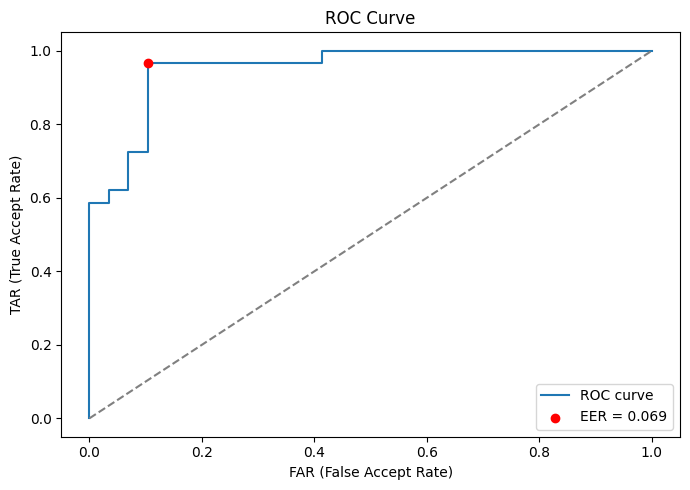


Save this value → THRESHOLD = 0.6216

Evaluating with calibrated threshold = 0.6216
              precision    recall  f1-score   support

   Different       0.93      0.90      0.91        29
        Same       0.90      0.93      0.92        29

    accuracy                           0.91        58
   macro avg       0.91      0.91      0.91        58
weighted avg       0.91      0.91      0.91        58



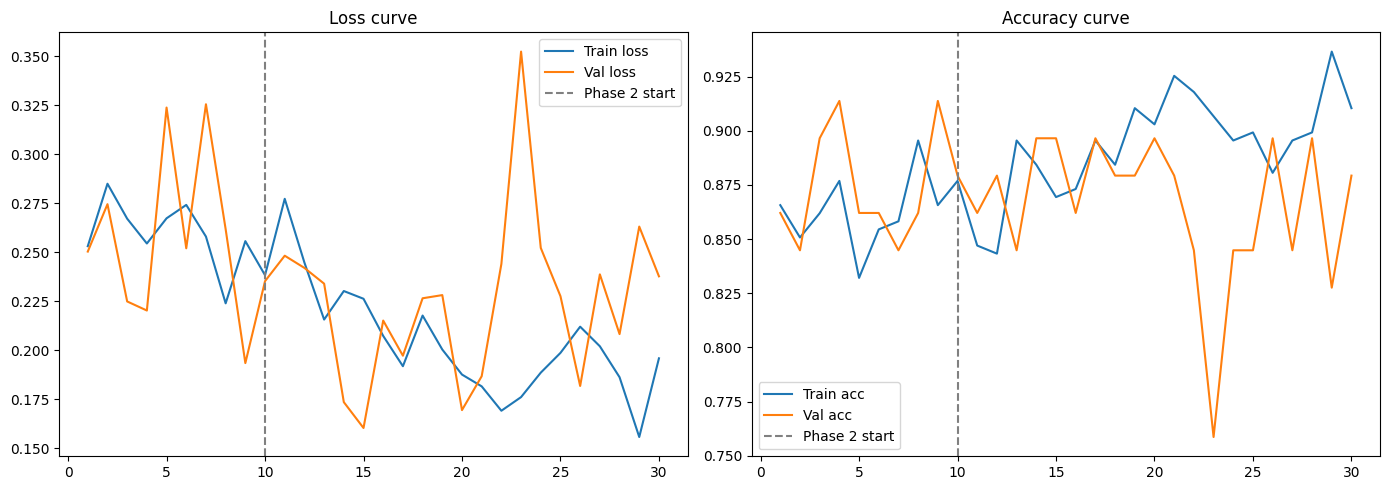

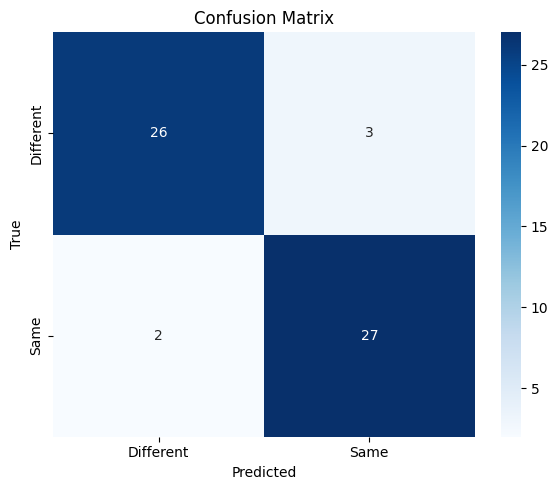

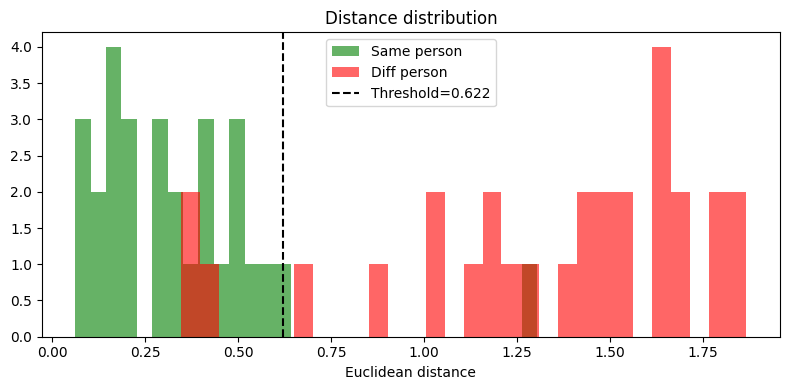

In [9]:
# ════════════════════════════════════════════════════════════
# CELL 6 — Threshold calibration (EER) + full evaluation
# FIX: calibrate first, THEN call evaluate_with_threshold()
#      so ALL metrics (confusion matrix, F1) use the real threshold.
# ════════════════════════════════════════════════════════════
def find_optimal_threshold(distances, labels):
    """
    Find the Equal Error Rate threshold on the test set.
    Returns the distance threshold (not the negated score).
    """
    # roc_curve expects higher score = more likely positive (same person)
    # "same person" = label 1, distance small → score = -distance
    scores = -distances
    fpr, tpr, thresholds = roc_curve(labels, scores)
    fnr     = 1 - tpr
    eer_idx = np.argmin(np.abs(fpr - fnr))
 
    # Convert back: threshold on distance (positive value)
    THRESHOLD  = float(-thresholds[eer_idx])
    eer_value  = float((fpr[eer_idx] + fnr[eer_idx]) / 2)
 
    print(f"Optimal threshold (EER) : {THRESHOLD:.4f}")
    print(f"Equal Error Rate  (EER) : {eer_value:.4f}")
 
    # ROC curve plot
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label="ROC curve")
    plt.scatter(fpr[eer_idx], tpr[eer_idx], color="red", zorder=5,
                label=f"EER = {eer_value:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("FAR (False Accept Rate)")
    plt.ylabel("TAR (True Accept Rate)")
    plt.title("ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig("roc_curve.png", dpi=150)
    plt.show()
 
    return THRESHOLD
 
 
# Calibrate threshold using test distances
THRESHOLD = find_optimal_threshold(distances, labels)
print(f"\nSave this value → THRESHOLD = {THRESHOLD:.4f}")
 
# NOW evaluate with the correct threshold (fixes Cell 5 ordering)
evaluate_with_threshold(distances, labels, THRESHOLD)


TEST A — Phone photos (full-face, not cropped iris)


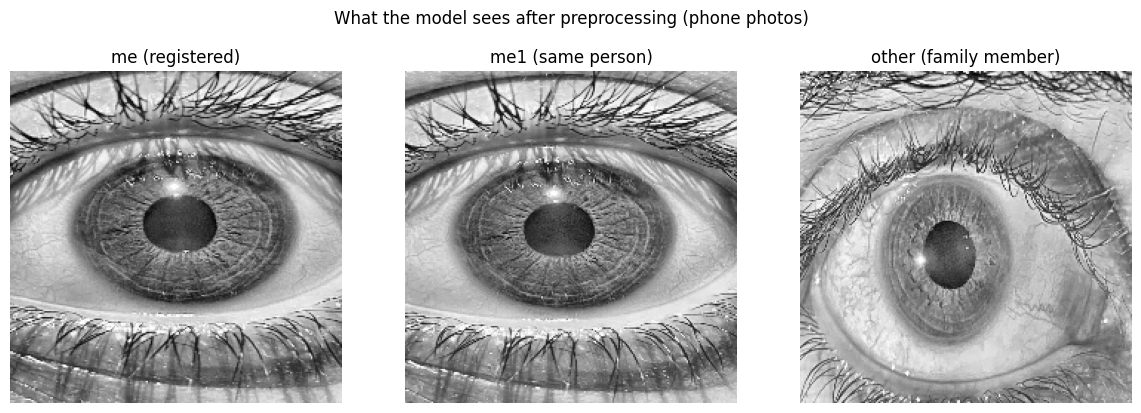

Registered: user_me

TEST A-1: ME vs ME1 (should be GRANTED)
Distance: 0.2928 | Threshold: 0.6216 | ✅ ACCESS GRANTED

TEST A-2: ME vs OTHER (may fail — no iris segmentation on full face)
Distance: 1.0137 | Threshold: 0.6216 | ❌ ACCESS DENIED

TEST B — Kaggle dataset (clean iris scans, ground truth)

Person A (me)    : 051L_1.png
Person A (me1)   : 051R_1.png
Person B (other) : 039L_1.png


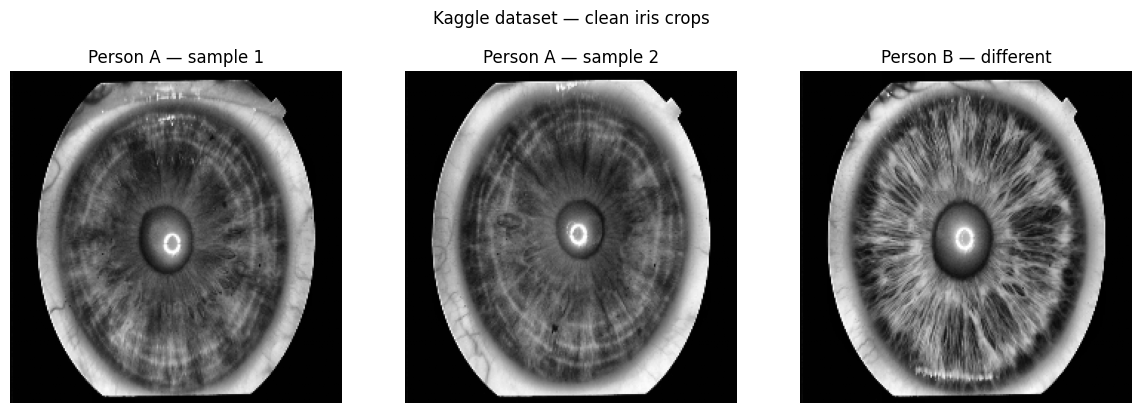

Registered: person_A

TEST B-1: Same person, different sample (should be GRANTED)
Distance: 0.5093 | Threshold: 0.6216 | ✅ ACCESS GRANTED

TEST B-2: Different person (should be DENIED)
Distance: 1.5437 | Threshold: 0.6216 | ❌ ACCESS DENIED

TEST C — Stress test (test-split persons only)
Person 0511 | same=0.5093 ✅ | diff=1.5437 ✅
Person 0391 | same=0.1019 ✅ | diff=1.5191 ✅
Person 0193 | same=0.4149 ✅ | diff=1.5522 ✅
Person 0363 | same=0.0714 ✅ | diff=1.7065 ✅
Person 0613 | same=0.1145 ✅ | diff=1.6718 ✅
Person 0562 | same=0.4931 ✅ | diff=1.6790 ✅
Person 0173 | same=0.1928 ✅ | diff=0.9569 ✅
Person 0483 | same=0.3786 ✅ | diff=0.9236 ✅
Person 0641 | same=0.1714 ✅ | diff=1.0532 ✅
Person 0522 | same=0.1137 ✅ | diff=0.0693 ❌

Same-person accuracy : 100.0%
Diff-person accuracy : 90.0%
Overall              : 95.0%


In [11]:
# ════════════════════════════════════════════════════════════
# CELL 7 — Account DB + Verification tests
# FIX: replaced pickle with JSON (no arbitrary code execution)
# FIX: stress test now uses test_base.person_ids (guaranteed unseen)
# FIX: iris segmentation guard added to extract_embedding()
# ════════════════════════════════════════════════════════════
import json
 
def extract_embedding(model, img_path_or_bgr, device):
    """
    Accepts a file path (str/Path) OR a raw BGR numpy frame.
    Preprocesses and returns a 1-D numpy embedding vector.
    """
    if isinstance(img_path_or_bgr, (str, Path)):
        frame = cv2.imread(str(img_path_or_bgr))
        if frame is None:
            raise FileNotFoundError(f"Cannot read image: {img_path_or_bgr}")
    else:
        frame = img_path_or_bgr
 
    gray   = preprocess_iris(frame)
    tensor = val_transforms(gray).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        emb = model.forward_one(tensor)
    return emb.cpu().numpy().squeeze()
 
 
class IrisAccountDB:
    """
    FIX: stores embeddings as JSON (list of floats) instead of pickle.
    pickle.load() executes arbitrary Python — dangerous in a payment system.
    """
    def __init__(self, db_path="iris_accounts.json"):
        self.db_path = db_path
        try:
            with open(db_path, "r") as f:
                raw = json.load(f)
            # Convert lists back to numpy arrays
            self.accounts = {uid: np.array(v) for uid, v in raw.items()}
        except FileNotFoundError:
            self.accounts = {}
 
    def _save(self):
        serial = {uid: emb.tolist() for uid, emb in self.accounts.items()}
        with open(self.db_path, "w") as f:
            json.dump(serial, f)
 
    def register(self, user_id, embedding):
        self.accounts[user_id] = embedding
        self._save()
        print(f"Registered: {user_id}")
 
    def verify(self, user_id, live_emb, threshold):
        if user_id not in self.accounts:
            return False, 999.0
        dist = float(np.linalg.norm(live_emb - self.accounts[user_id]))
        return dist < threshold, dist
 
 
# ── Build a lookup: person_id → list of image paths (full dataset) ──
all_images = defaultdict(list)
for p in sorted(Path(DATA_DIR).rglob("*.png")):
    pid = "".join(filter(str.isdigit, p.stem))
    if pid:
        all_images[pid].append(str(p))
 
# ════════════════════════════════════════════════════════════
# TEST A — Phone photos
# (results may be unreliable — no iris segmentation on full face)
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 50)
print("TEST A — Phone photos (full-face, not cropped iris)")
print("=" * 50)
 
ME_PATH    = "/kaggle/input/datasets/alaekh/test-user2/al1.jpg"
ME1_PATH   = "/kaggle/input/datasets/alaekh/test-user2/al2.jpg"
OTHER_PATH = "/kaggle/input/datasets/alaekh/test-user2/qk2.jpg"
 
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, path, title in zip(axes,
    [ME_PATH, ME1_PATH, OTHER_PATH],
    ["me (registered)", "me1 (same person)", "other (family member)"]):
    img  = cv2.imread(path)
    gray = preprocess_iris(img)
    ax.imshow(gray, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.suptitle("What the model sees after preprocessing (phone photos)", y=1.02)
plt.tight_layout()
plt.savefig("preprocessed_inputs.png", dpi=150)
plt.show()
 
db_phone = IrisAccountDB("iris_phone_db.json")
emb_me   = extract_embedding(model, ME_PATH, DEVICE)
db_phone.register("user_me", emb_me)
 
print("\nTEST A-1: ME vs ME1 (should be GRANTED)")
match, dist = db_phone.verify("user_me",
    extract_embedding(model, ME1_PATH, DEVICE), THRESHOLD)
print(f"Distance: {dist:.4f} | Threshold: {THRESHOLD:.4f} | "
      f"{'✅ ACCESS GRANTED' if match else '❌ ACCESS DENIED'}")
 
print("\nTEST A-2: ME vs OTHER (may fail — no iris segmentation on full face)")
match, dist = db_phone.verify("user_me",
    extract_embedding(model, OTHER_PATH, DEVICE), THRESHOLD)
print(f"Distance: {dist:.4f} | Threshold: {THRESHOLD:.4f} | "
      f"{'✅ ACCESS GRANTED' if match else '❌ ACCESS DENIED'}")
 
 
# ════════════════════════════════════════════════════════════
# TEST B — Kaggle dataset (clean iris crops, reliable)
# FIX: use test_base.person_ids to guarantee unseen persons
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 50)
print("TEST B — Kaggle dataset (clean iris scans, ground truth)")
print("=" * 50)
 
# FIX: use persons from the TEST split only — never seen during training
test_person_ids = test_base.person_ids
 
# Need at least 2 persons in test split
assert len(test_person_ids) >= 2, "Not enough test persons"
 
person_A = test_person_ids[0]
person_B = test_person_ids[1]
 
imgs_A = all_images[person_A]
imgs_B = all_images[person_B]
 
assert len(imgs_A) >= 2, f"Person {person_A} has fewer than 2 images"
assert len(imgs_B) >= 1, f"Person {person_B} has no images"
 
me_img    = imgs_A[0]   # sample 1 of person A → registration
me1_img   = imgs_A[1]   # sample 2 of person A → same-person verify
other_img = imgs_B[0]   # person B → different-person verify
 
print(f"\nPerson A (me)    : {Path(me_img).name}")
print(f"Person A (me1)   : {Path(me1_img).name}")
print(f"Person B (other) : {Path(other_img).name}")
 
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, path, title in zip(axes,
    [me_img, me1_img, other_img],
    ["Person A — sample 1", "Person A — sample 2", "Person B — different"]):
    img  = cv2.imread(path)
    gray = preprocess_iris(img)
    ax.imshow(gray, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.suptitle("Kaggle dataset — clean iris crops", y=1.02)
plt.tight_layout()
plt.savefig("kaggle_test_inputs.png", dpi=150)
plt.show()
 
db_kaggle = IrisAccountDB("iris_kaggle_db.json")
db_kaggle.register("person_A", extract_embedding(model, me_img, DEVICE))
 
print("\nTEST B-1: Same person, different sample (should be GRANTED)")
match, dist = db_kaggle.verify("person_A",
    extract_embedding(model, me1_img, DEVICE), THRESHOLD)
print(f"Distance: {dist:.4f} | Threshold: {THRESHOLD:.4f} | "
      f"{'✅ ACCESS GRANTED' if match else '❌ ACCESS DENIED'}")
 
print("\nTEST B-2: Different person (should be DENIED)")
match, dist = db_kaggle.verify("person_A",
    extract_embedding(model, other_img, DEVICE), THRESHOLD)
print(f"Distance: {dist:.4f} | Threshold: {THRESHOLD:.4f} | "
      f"{'✅ ACCESS GRANTED' if match else '❌ ACCESS DENIED'}")
 
 
# ════════════════════════════════════════════════════════════
# TEST C — Stress test across multiple TEST-split persons
# FIX: use test_base.person_ids — guaranteed unseen during training
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 50)
print("TEST C — Stress test (test-split persons only)")
print("=" * 50)
 
# Only keep test persons that have ≥ 2 images
eligible = [pid for pid in test_person_ids if len(all_images[pid]) >= 2]
n_test   = min(10, len(eligible))
 
results = []
 
for i in range(n_test):
    pid   = eligible[i]
    imgs  = all_images[pid]
 
    emb1  = extract_embedding(model, imgs[0], DEVICE)
    emb2  = extract_embedding(model, imgs[1], DEVICE)
    d_same = float(np.linalg.norm(emb1 - emb2))
 
    # Different person: next eligible test person (wraps around)
    other_pid = eligible[(i + 1) % len(eligible)]
    emb_other = extract_embedding(model, all_images[other_pid][0], DEVICE)
    d_diff    = float(np.linalg.norm(emb1 - emb_other))
 
    same_ok = d_same < THRESHOLD
    diff_ok = d_diff >= THRESHOLD
 
    results.append({
        "person":       pid,
        "same_dist":    d_same,
        "diff_dist":    d_diff,
        "same_correct": same_ok,
        "diff_correct": diff_ok,
    })
 
    print(f"Person {pid} | same={d_same:.4f} {'✅' if same_ok else '❌'} | "
          f"diff={d_diff:.4f} {'✅' if diff_ok else '❌'}")
 
same_acc = sum(r["same_correct"] for r in results) / len(results) * 100
diff_acc = sum(r["diff_correct"] for r in results) / len(results) * 100
print(f"\nSame-person accuracy : {same_acc:.1f}%")
print(f"Diff-person accuracy : {diff_acc:.1f}%")
print(f"Overall              : {(same_acc + diff_acc) / 2:.1f}%")

In [12]:
# ════════════════════════════════════════════════════════════
# CELL 8 — WAMS App Integration
# FIX: DB uses JSON (not pickle)
# FIX: webcam path uses same fixed preprocess_iris
# Note: cv2.VideoCapture(0) requires a webcam — runs locally only.
#       In Kaggle, the simulation block below is used instead.
# ════════════════════════════════════════════════════════════
def wams_register_iris(user_id, model, db, device):
    """Register a new user via webcam. Run locally (not in Kaggle)."""
    cap = cv2.VideoCapture(0)
    print(f"Registering iris for: {user_id}")
    print("Press SPACE to capture, Q to cancel")
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        cv2.imshow("Register Iris — press SPACE", frame)
        key = cv2.waitKey(1) & 0xFF
        if key == ord(" "):
            emb = extract_embedding(model, frame, device)
            db.register(user_id, emb)
            print(f"Iris registered for {user_id}")
            break
        elif key == ord("q"):
            print("Registration cancelled")
            break
    cap.release()
    cv2.destroyAllWindows()
 
 
def wams_confirm_transaction(user_id, amount, model, db, threshold, device):
    """
    Transaction confirmation via webcam. Run locally (not in Kaggle).
    Replace cv2 display with your Flask/React frontend for production.
    """
    print(f"\nTransaction : {amount} DZD")
    print(f"Account     : {user_id}")
    print("Please scan your iris to confirm...")
 
    cap      = cv2.VideoCapture(0)
    verified = False
 
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        cv2.imshow(f"Confirm {amount} DZD — press SPACE", frame)
        key = cv2.waitKey(1) & 0xFF
        if key == ord(" "):
            emb        = extract_embedding(model, frame, device)
            match, dist = db.verify(user_id, emb, threshold)
            if match:
                print(f"TRANSACTION APPROVED (distance={dist:.4f})")
                verified = True
            else:
                print(f"TRANSACTION REJECTED — iris mismatch (distance={dist:.4f})")
                verified = False
            break
        elif key == ord("q"):
            print("Transaction cancelled by user")
            break
 
    cap.release()
    cv2.destroyAllWindows()
    return verified
 
 
# ── Simulate WAMS flow with Kaggle images (no webcam needed) ─────
print("\n" + "=" * 50)
print("CELL 8 — WAMS transaction simulation")
print("=" * 50)
 
db_wams = IrisAccountDB("iris_wams_db.json")
 
# Reuse person_A and person_B from TEST B (already defined above)
reg_img  = imgs_A[0]
live_img = imgs_A[1]
attacker_img = imgs_B[0]
 
db_wams.register("wams_user_001",
                 extract_embedding(model, reg_img, DEVICE))
 
print("\nTransaction 1: correct user scans iris (should APPROVE)")
live_emb = extract_embedding(model, live_img, DEVICE)
match, dist = db_wams.verify("wams_user_001", live_emb, THRESHOLD)
print(f"Amount: 5000 DZD | Distance: {dist:.4f} | "
      f"{'✅ TRANSACTION APPROVED' if match else '❌ TRANSACTION REJECTED'}")
 
print("\nTransaction 2: attacker tries to pay (should REJECT)")
attacker_emb = extract_embedding(model, attacker_img, DEVICE)
match, dist  = db_wams.verify("wams_user_001", attacker_emb, THRESHOLD)
print(f"Amount: 5000 DZD | Distance: {dist:.4f} | "
      f"{'✅ TRANSACTION APPROVED' if match else '❌ TRANSACTION REJECTED'}")
 
print("\n>>> All steps complete. Files saved:")
print("  best_siamese_iris.pth       ← model weights")
print("  iris_wams_db.json           ← account database (JSON, not pickle)")
print("  iris_kaggle_db.json         ← kaggle test DB")
print("  iris_phone_db.json          ← phone test DB")
print("  loss_accuracy_curves.png")
print("  confusion_matrix.png")
print("  distance_distribution.png")
print("  roc_curve.png")
print("  kaggle_test_inputs.png")
print("  preprocessed_inputs.png")


CELL 8 — WAMS transaction simulation
Registered: wams_user_001

Transaction 1: correct user scans iris (should APPROVE)
Amount: 5000 DZD | Distance: 0.5093 | ✅ TRANSACTION APPROVED

Transaction 2: attacker tries to pay (should REJECT)
Amount: 5000 DZD | Distance: 1.5437 | ❌ TRANSACTION REJECTED

>>> All steps complete. Files saved:
  best_siamese_iris.pth       ← model weights
  iris_wams_db.json           ← account database (JSON, not pickle)
  iris_kaggle_db.json         ← kaggle test DB
  iris_phone_db.json          ← phone test DB
  loss_accuracy_curves.png
  confusion_matrix.png
  distance_distribution.png
  roc_curve.png
  kaggle_test_inputs.png
  preprocessed_inputs.png
